## Data Preparation

In [14]:
import numpy as np
import pandas as  pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

In [15]:
with open("../Analysis/players.sql") as f:
    players = f.read()
players_queries = players.split(";")

with open("../Analysis/schools.sql") as f:
    schools= f.read()
schools_queries = schools.split(";")

with open("../Analysis/salaries.sql") as f:
    salaries = f.read()
salaries_queries = salaries.split(";")

In [16]:
load_dotenv()
user = os.getenv("user")
password = os.getenv("password")
host = os.getenv("host")
port = os.getenv("port")
db = os.getenv("db")
engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}")

In [17]:
height_weight = pd.read_sql(players_queries[3], engine)
n_schools_decades = pd.read_sql(schools_queries[2], engine)
top5_schools = pd.read_sql(schools_queries[3], engine)
top_20_perc_teams = pd.read_sql(salaries_queries[0], engine)
cum_spending_over_years = pd.read_sql(salaries_queries[1], engine)

In [18]:
total_cumulative = (cum_spending_over_years
                    .pivot_table(index="yearid", 
                                 columns="teamid", 
                                 values="cumsum", 
                                 aggfunc="sum", 
                                 margins=True)
                    [["All"]].iloc[:-1])

total_cumulative = total_cumulative.reset_index().set_index("yearid")
total_cumulative["All"] = total_cumulative["All"]/1_000_000_000


top_20_perc_teams.sort_values("avg_annual_spending",inplace=True)
top_20_perc_teams["avg_annual_spending"] = top_20_perc_teams["avg_annual_spending"]/1_000_000


## Visualization

In [19]:
plt.rc("axes", linewidth=.5)
plt.rc("axes.spines", top=False, right=False)
plt.style.use("seaborn-v0_8-notebook")
plt.rcParams["font.sans-serif"] = "Arial"

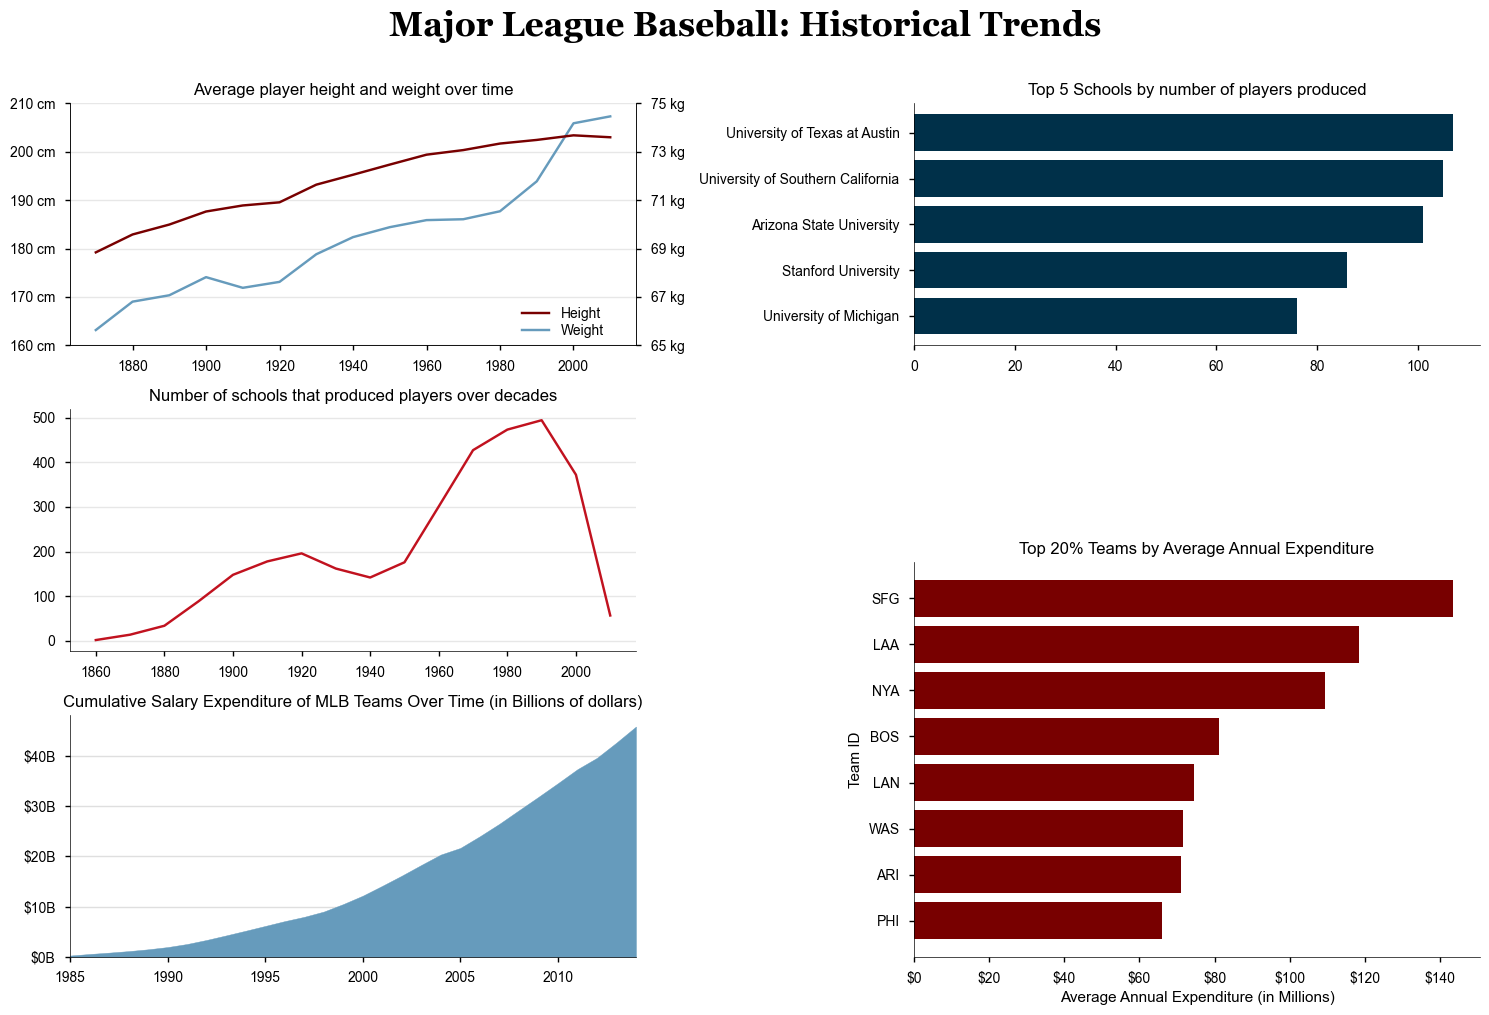

In [20]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(15,10))
gs = gridspec.GridSpec(nrows=6, ncols=2)

ax1 = fig.add_subplot(gs[0:2, 0])
ax3 = fig.add_subplot(gs[2:4, 0])
ax4 = fig.add_subplot(gs[4:6, 0])
ax5 = fig.add_subplot(gs[0:2, 1])
ax6 = fig.add_subplot(gs[3:6, 1])


#------------------------------------------------------------------------------------------------
# HEIGHT AND WEIGHT
#------------------------------------------------------------------------------------------------
ax2 = ax1.twinx()
ax1.plot(height_weight["debut_decade"], height_weight["avg_height"], color="#669bbc", label="Weight")
ax2.plot(height_weight["debut_decade"], height_weight["avg_weight"],color="#780000", label="Height" )

ax1.spines["right"].set_visible(True)
ax2.spines["right"].set_visible(True)
ax1.set_ylim(160,210)
ax1.yaxis.set_major_formatter("{x:.0f} cm")
ax2.set_yticks(np.linspace(65,75,6))
ax2.yaxis.set_major_formatter("{x:.0f} kg")
ax1.grid(True, alpha=0.3, axis="y")

ax1.set_title("Average player height and weight over time", fontname="Arial")
ax2.legend(bbox_to_anchor=(0.96,0.21), frameon=False)
ax1.legend(bbox_to_anchor=(0.965,0.14), frameon=False)


#------------------------------------------------------------------------------------------------
# NUMBER OF SCHOOLS THAT PRODUCED PLAYERS
#------------------------------------------------------------------------------------------------
ax3.plot(n_schools_decades.set_index("decade"), color="#c1121f")
ax3.set_title("Number of schools that produced players over decades")
ax3.grid(True, alpha=.3, axis="y")


#------------------------------------------------------------------------------------------------
# CUMULATIVE SPENDING
#------------------------------------------------------------------------------------------------
ax4.stackplot(total_cumulative.index, total_cumulative["All"],zorder=2, color="#669bbc")
ax4.set_xlim(1985, 2014)
ax4.set_title("Cumulative Salary Expenditure of MLB Teams Over Time (in Billions of dollars)")
ax4.yaxis.set_major_formatter("${x:,.0f}B")
ax4.grid(True, alpha=.4, axis="y", zorder=0)

#------------------------------------------------------------------------------------------------
# TOP 5 SCHOOLS
#------------------------------------------------------------------------------------------------
top5_schools.sort_values("n_players", inplace=True)
ax5.barh(y=top5_schools["name_full"],width=top5_schools["n_players"], color="#003049")
ax5.set_title("Top 5 Schools by number of players produced")

#------------------------------------------------------------------------------------------------
# TOP 20% SCHOOL
#------------------------------------------------------------------------------------------------

ax6.barh(top_20_perc_teams["teamid"], top_20_perc_teams["avg_annual_spending"], color="#780000")
ax6.set_title("Top 20% Teams by Average Annual Expenditure")
ax6.set_xlabel("Average Annual Expenditure (in Millions)")
ax6.set_ylabel("Team ID")
ax6.xaxis.set_major_formatter("${x:,.0f}")

fig.suptitle("Major League Baseball: Historical Trends", fontname="Georgia", fontsize=24, fontweight="bold", y=1.01)    
plt.tight_layout()
plt.savefig("MLB dashboard.png", dpi=300, bbox_inches="tight", pad_inches=.5)
plt.show()